# Subgenre annotations (pre-1800)

Sonnet's `subgenre` annotation task (892 pre-1800 texts) tags each with:

- **is_fiction**: bool — does this text count as fiction at all? (caught 139 non-fiction, 15.6%)
- **non_fiction_type**: type tag for the non-fiction texts
- **subgenres**: list of subgenre tags (38 distinct), e.g. `amatory_fiction`, `sentimental`, `domestic_fiction`, `gothic`, `picaresque`, etc.

Companion to `16-plot-genre.ipynb`. Two main analyses:
1. Surface the non-fiction set so we can decide later whether to filter from §15's social-network analysis.
2. Track the rise-of-the-novel transition in subgenre terms (`amatory → sentimental → domestic`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
from collections import Counter
from lltk.annotate import iter_task_results

plt.rcParams['figure.dpi'] = 110

DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

df_net = pd.read_csv('../data/social_networks/social_network_analysis.csv')

rows = []
for _id, d in iter_task_results('subgenre'):
    rows.append({
        'source': _id,
        'is_fiction': d.get('is_fiction'),
        'non_fiction_type': d.get('non_fiction_type'),
        'subgenres': d.get('subgenres') or [],
    })
sg = pd.DataFrame(rows)

df = sg.merge(df_net[['source', 'year', 'author', 'title', 'form',
                      'n_chars', 'realistic_pct', 'classical_pct', 'type_pct',
                      'comp_density', 'comp_clustering', 'char_desc_conc']],
              on='source', how='left')
print(f'subgenre rows: {len(sg):,}')
print(f'  with year:      {df["year"].notna().sum():,}')
print(f'  is_fiction True/False: {df["is_fiction"].sum()} / {(df["is_fiction"]==False).sum()}')
df.head(3)

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


subgenre rows: 892
  with year:      851
  is_fiction True/False: 753 / 139


,source,is_fiction,non_fiction_type,subgenres,year,author,title,form,n_chars,realistic_pct,classical_pct,type_pct,comp_density,comp_clustering,char_desc_conc
0,_chadwyck/Early_English_Prose_Fiction/ee01010.01,True,None,"[amatory_fiction, scandalous_memoir, secret_hi...",1699.0,Anon.,The Adventures of Covent&hyphen;Garden (1699),romance,6.0,0.0,33.3,16.7,0.2667,0.2778,-0.467551
1,_chadwyck/Early_English_Prose_Fiction/ee01010.02,True,None,"[frame_tale, amatory_fiction, domestic_fiction...",1696.0,Anon.,Alcander and Philocrates (1696),romance,32.0,3.1,15.6,46.9,0.0474,0.2109,-0.524978
2,_chadwyck/Early_English_Prose_Fiction/ee01010.03,True,None,"[pseudo_memoir, scandalous_memoir, historical_...",1663.0,Anon.,The Case of Madam Mary Carlton (1663),?,26.0,73.1,0.0,11.5,0.0369,0.0201,-0.195659


## 1. The non-fiction filter

What did Sonnet flag as non-fiction? Distribution by type, year, and corpus.

In [2]:
nonfic = df[df['is_fiction'] == False].copy()
print(f'{len(nonfic):,} non-fiction texts ({len(nonfic)/len(df)*100:.1f}% of subgenre-tagged)')
print()
print('=== non_fiction_type distribution ===')
print(nonfic['non_fiction_type'].value_counts(dropna=False).to_string())
print()

nonfic['decade'] = (nonfic['year'] // 10 * 10).astype('Int64')
print('=== non-fiction by decade (counts) ===')
print(nonfic.groupby('decade').size().to_string())
print()

# Sample some non-fiction titles
print('=== 25 non-fiction examples (titles) ===')
samp = nonfic[['year', 'author', 'title', 'non_fiction_type']].sort_values('year').head(25)
print(samp.to_string(index=False))

139 non-fiction texts (15.6% of subgenre-tagged)

=== non_fiction_type distribution ===
non_fiction_type
treatise      29
poetry        28
essay         22
history       18
biography      9
reference      9
letters        7
legal          6
sermon         5
drama          2
None           2
almanac        1
periodical     1

=== non-fiction by decade (counts) ===
decade
1480     1
1490     1
1500     1
1530     3
1560     2
1570     5
1580     7
1590     9
1600    19
1610     6
1620     6
1630     7
1640     4
1650     1
1660     1
1670     3
1680     6
1690     4
1700     3
1710     1
1720     2
1740     1
1750     2
1760     2
1780     1
1790     4

=== 25 non-fiction examples (titles) ===
  year                author                                              title non_fiction_type
1484.0        La Tour Landry [Here begynneth the booke which the knyght of the          treatise
1496.0               Joannes           [The lyfe of the thre kynges of Coleyne]          history
1503.0  

### Plot: non-fiction share over time

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_nonfiction_share_25y.png


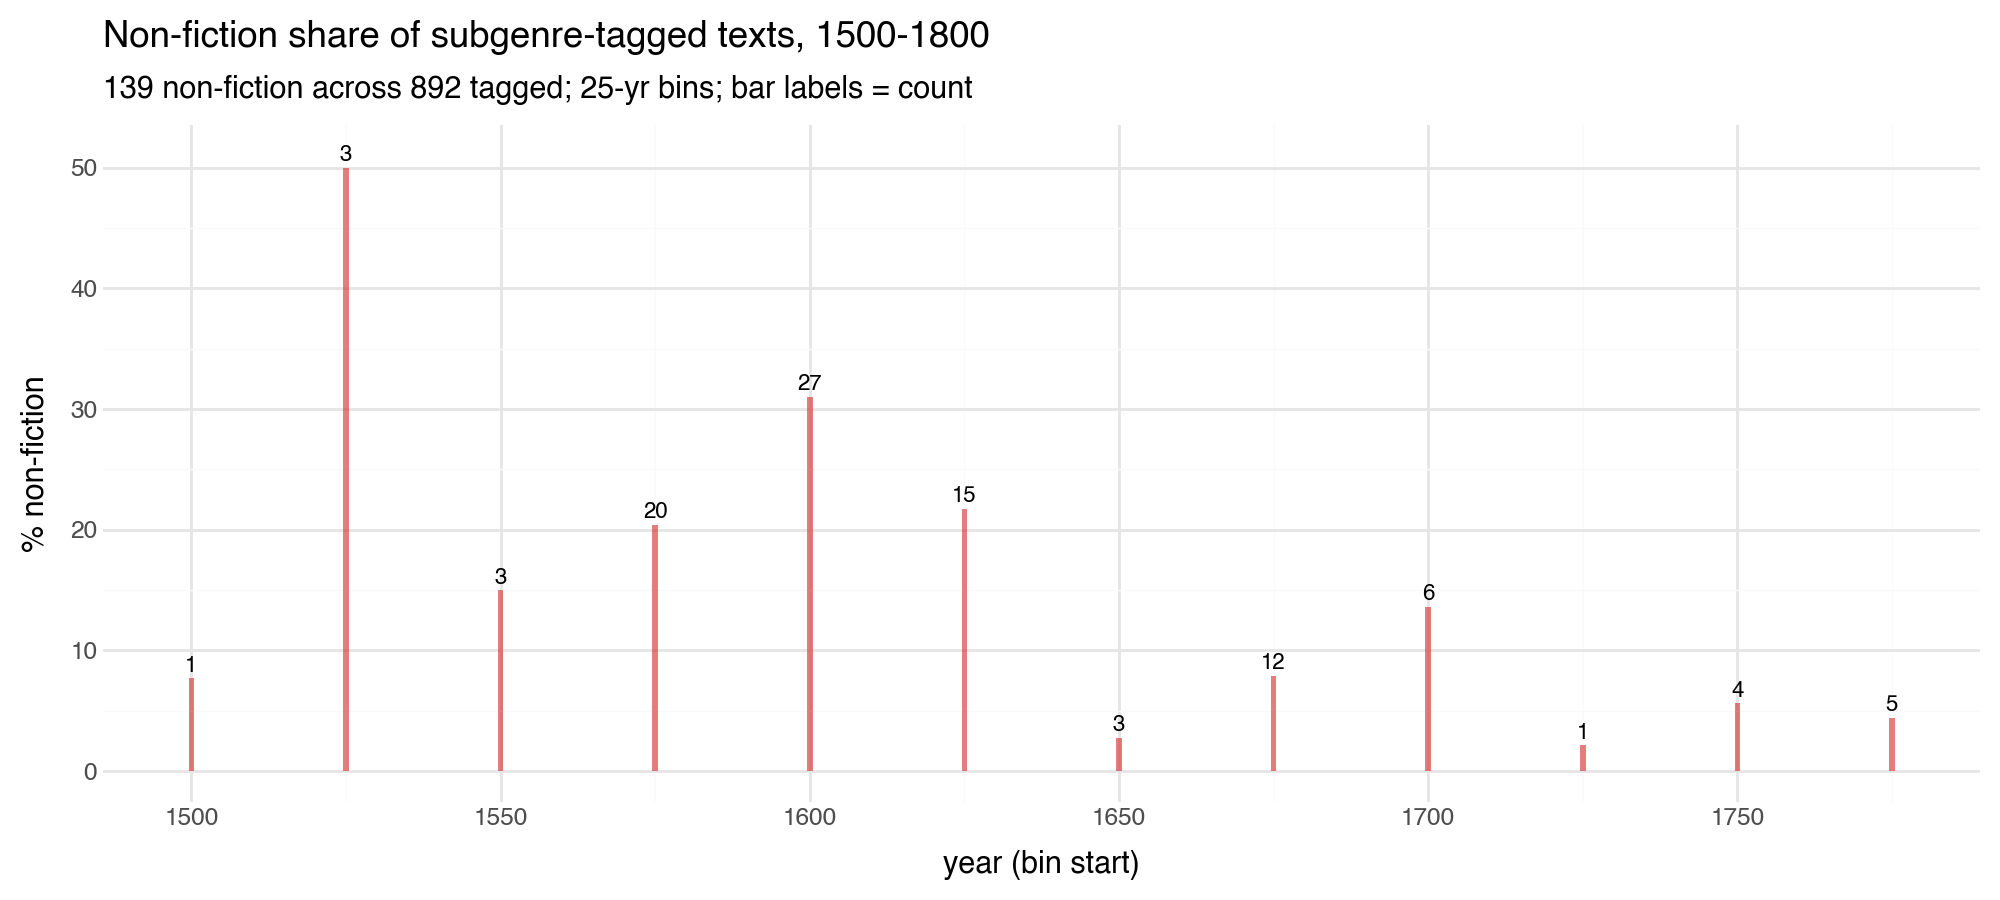

In [3]:
dia = df[(df['year'] >= 1500) & (df['year'] < 1800)].copy()
dia['bin'] = (dia['year'] // 25 * 25).astype(int)
nf_by_bin = (dia.groupby('bin')
             .agg(total=('source', 'count'),
                  nonfic=('is_fiction', lambda s: (s == False).sum()))
             .reset_index())
nf_by_bin['pct'] = nf_by_bin['nonfic'] / nf_by_bin['total'] * 100

p_nf = (p9.ggplot(nf_by_bin, p9.aes(x='bin', y='pct'))
        + p9.geom_col(fill='#d62728', alpha=0.6)
        + p9.geom_text(p9.aes(label='nonfic'), nudge_y=1, size=8)
        + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
        + p9.labs(
            title='Non-fiction share of subgenre-tagged texts, 1500-1800',
            subtitle=f'{(df["is_fiction"]==False).sum()} non-fiction across {len(df):,} tagged; 25-yr bins; bar labels = count',
            x='year (bin start)', y='% non-fiction',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(10, 4.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_nonfiction_share_25y.png')
p_nf.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_nf

**Decision deferred** — these 139 texts are visible above but NOT filtered from any other notebook. Decide later whether to propagate `is_fiction == True` as a global filter or treat case-by-case.

## 2. Subgenre vocabulary

Each text can have multiple subgenre tags. Total tags and frequency.

In [4]:
# Explode the list-valued subgenres
fic = df[df['is_fiction'] == True].copy()
sg_counter = Counter()
for tags in fic['subgenres']:
    for t in tags:
        sg_counter[t] += 1
print(f'{len(sg_counter)} distinct subgenre tags across {len(fic):,} fiction texts')
print()
print('Counts:')
for tag, n in sg_counter.most_common():
    print(f'  {n:5}  {tag}')

38 distinct subgenre tags across 753 fiction texts

Counts:
    292  sentimental
    219  frame_tale
    215  historical_fiction
    211  domestic_fiction
    177  amatory_fiction
    169  heroic_romance
    133  pseudo_memoir
    104  picaresque
    100  menippean_satire
     99  allegory
     98  philosophical_tale
     85  travel_narrative
     79  conduct_fiction
     78  epistolary
     63  rogue_fiction
     54  scandalous_memoir
     47  pastoral
     37  secret_history
     32  gothic
     27  newgate_narrative
     27  imaginary_voyage
     25  roman_a_clef
     25  anti_romance
     22  fabliau
     21  captivity_narrative
     20  oriental_tale
     20  parody
     19  exemplum
     18  fairy_tale
     18  beast_fable
     17  anatomy
     15  providence_tale
     14  spiritual_autobiography
     11  robinsonade
     11  children_fiction
      9  jacobin_novel
      8  national_tale
      4  it_narrative


## 3. Subgenre composition over time (top-12)

For the 12 most-common subgenres, plot per-bin share of fiction texts that carry the tag (multi-label, so shares can sum to >100%).

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_top12_25y.png


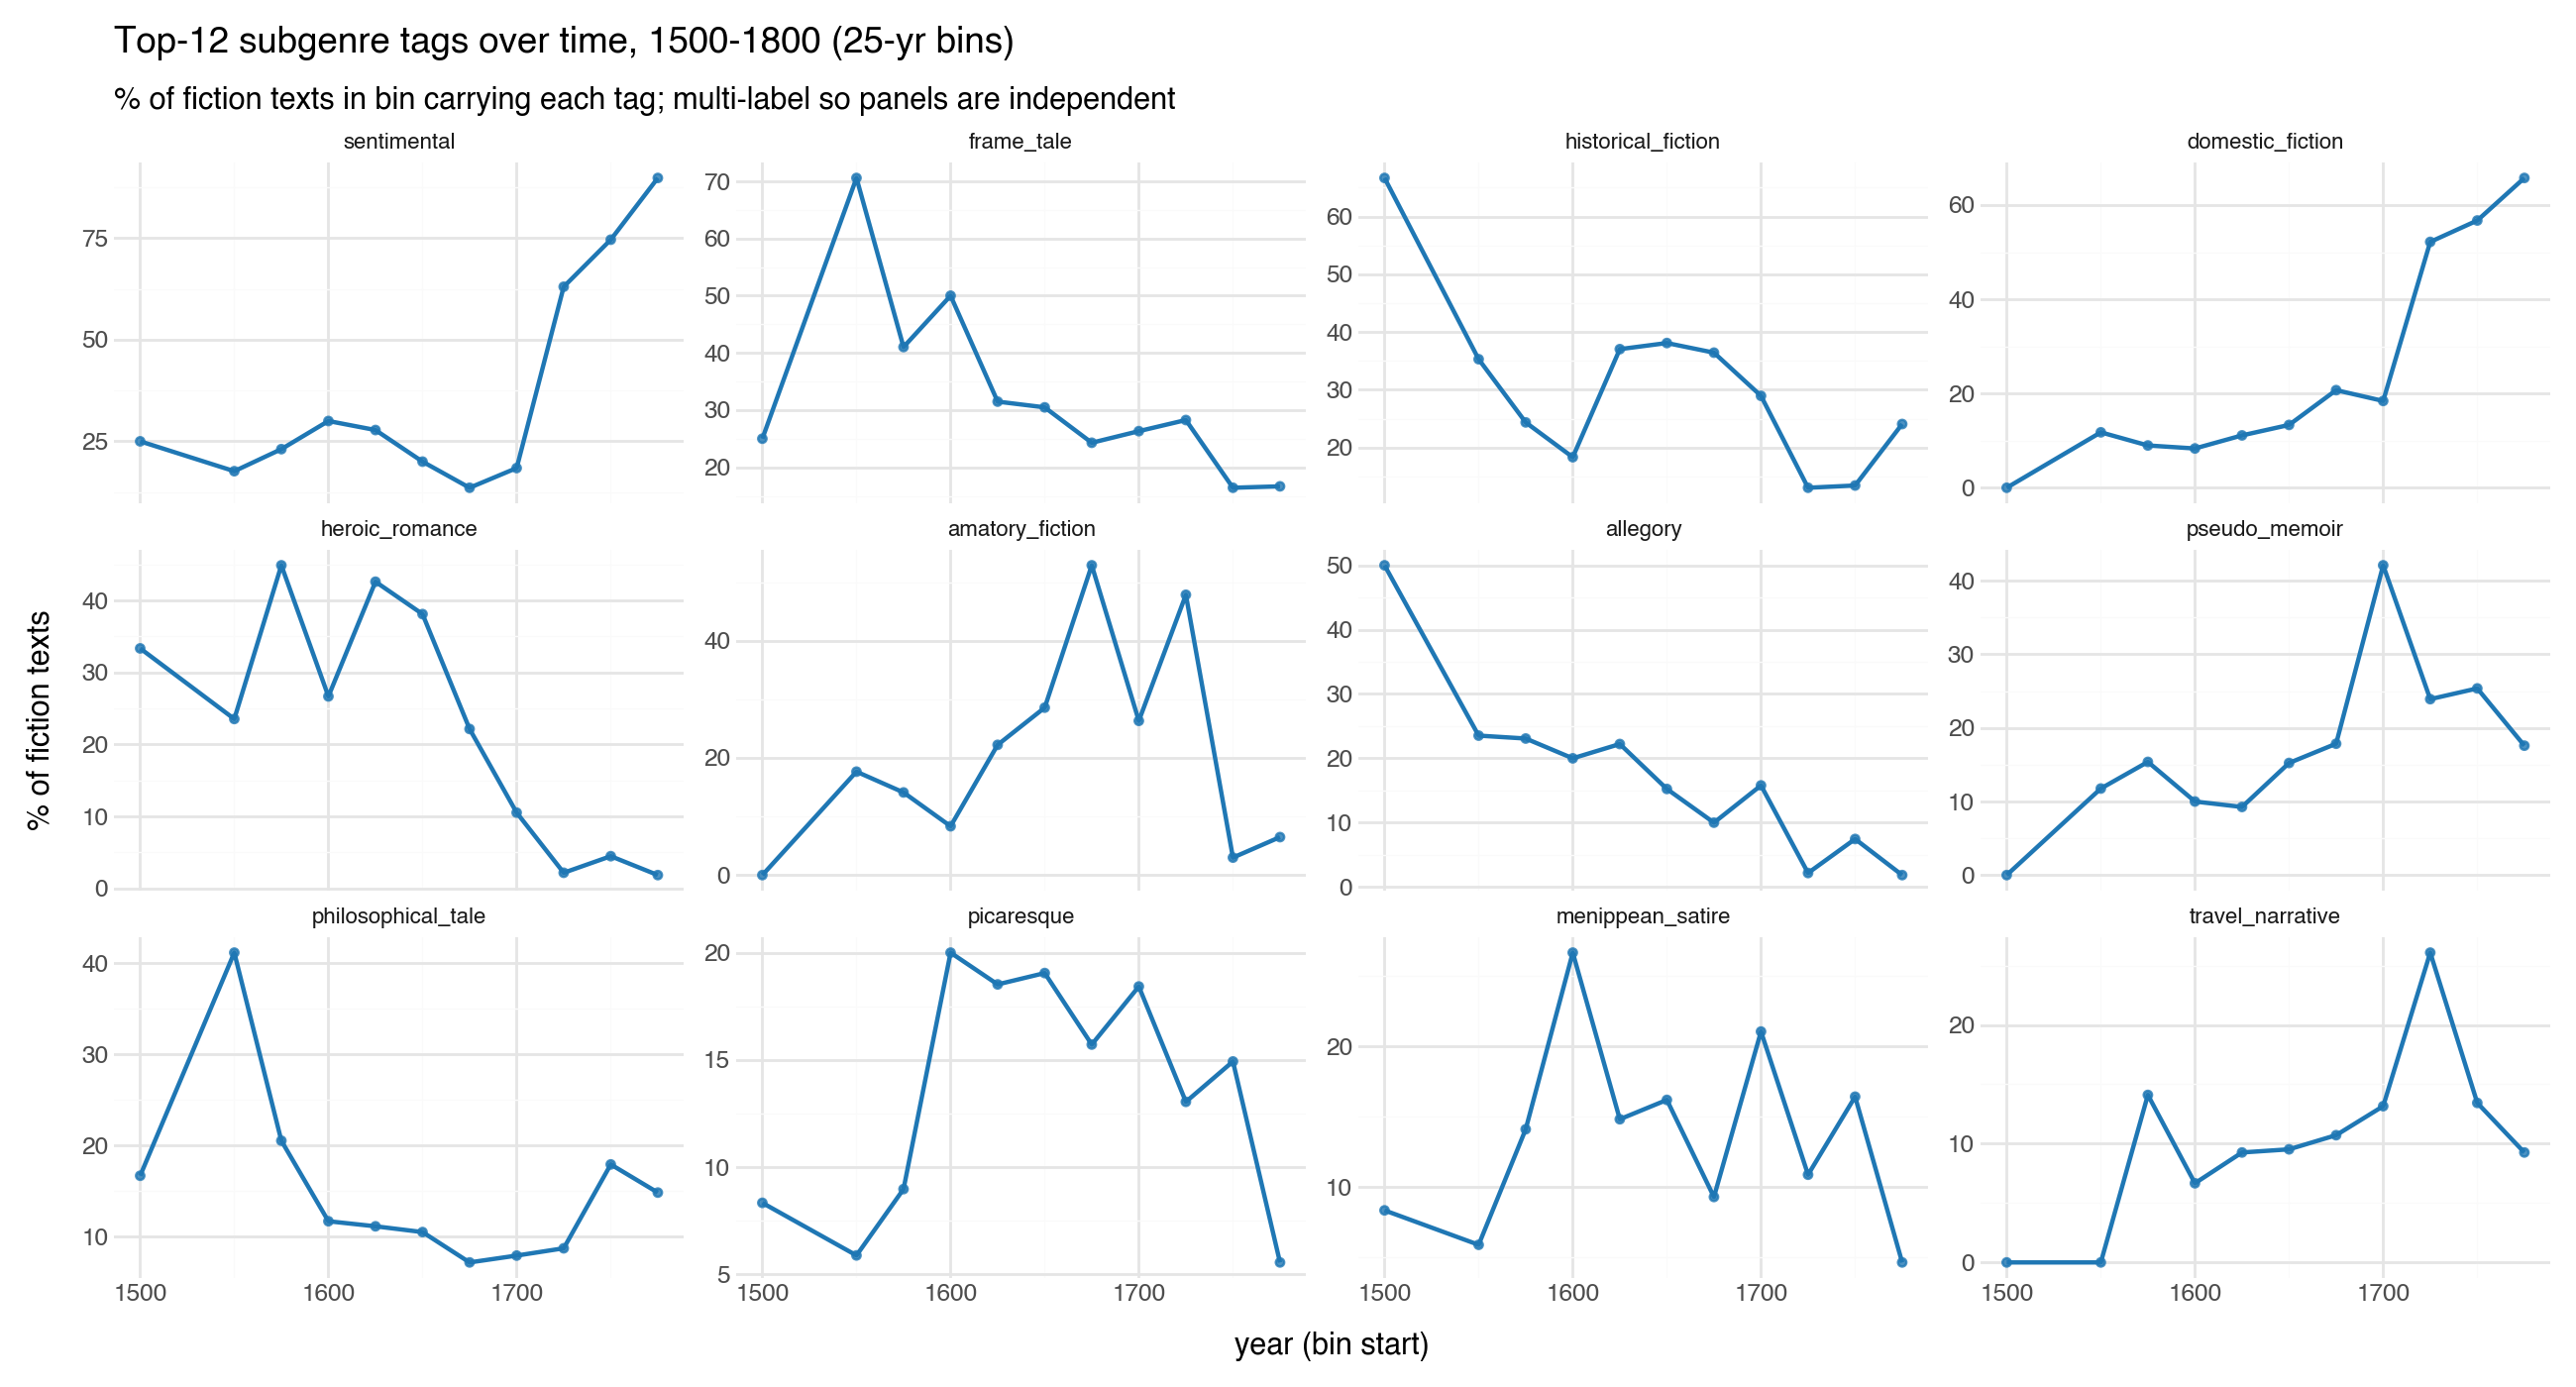

In [5]:
TOP_K = 12
MIN_N = 8
top_tags = [t for t, _ in sg_counter.most_common(TOP_K)]

dia = fic[(fic['year'] >= 1500) & (fic['year'] < 1800)].copy()
dia['bin'] = (dia['year'] // 25 * 25).astype(int)

long_rows = []
for tag in top_tags:
    has_tag = dia['subgenres'].apply(lambda L: tag in L)
    grp = dia.assign(has_tag=has_tag).groupby('bin').agg(
        n=('has_tag', 'sum'),
        total=('has_tag', 'count'),
    ).reset_index()
    grp = grp[grp['total'] >= MIN_N].copy()
    grp['pct'] = grp['n'] / grp['total'] * 100
    grp['subgenre'] = tag
    long_rows.append(grp)
sg_long = pd.concat(long_rows, ignore_index=True)

# Order facets by overall mean pct
order = (sg_long.groupby('subgenre')['pct'].mean()
         .sort_values(ascending=False).index.tolist())
sg_long['subgenre'] = pd.Categorical(sg_long['subgenre'], categories=order, ordered=True)

p_sg = (p9.ggplot(sg_long, p9.aes(x='bin', y='pct'))
        + p9.geom_line(color='#1f77b4', size=0.9)
        + p9.geom_point(color='#1f77b4', size=1.2, alpha=0.8)
        + p9.facet_wrap('~ subgenre', ncol=4, scales='free_y')
        + p9.scale_x_continuous(breaks=range(1500, 1801, 100))
        + p9.labs(
            title=f'Top-{TOP_K} subgenre tags over time, 1500-1800 (25-yr bins)',
            subtitle=f'% of fiction texts in bin carrying each tag; multi-label so panels are independent',
            x='year (bin start)', y='% of fiction texts',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 7),
                   strip_text=p9.element_text(size=8)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_top12_25y.png')
p_sg.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_sg

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_top12_25y_overlay.png


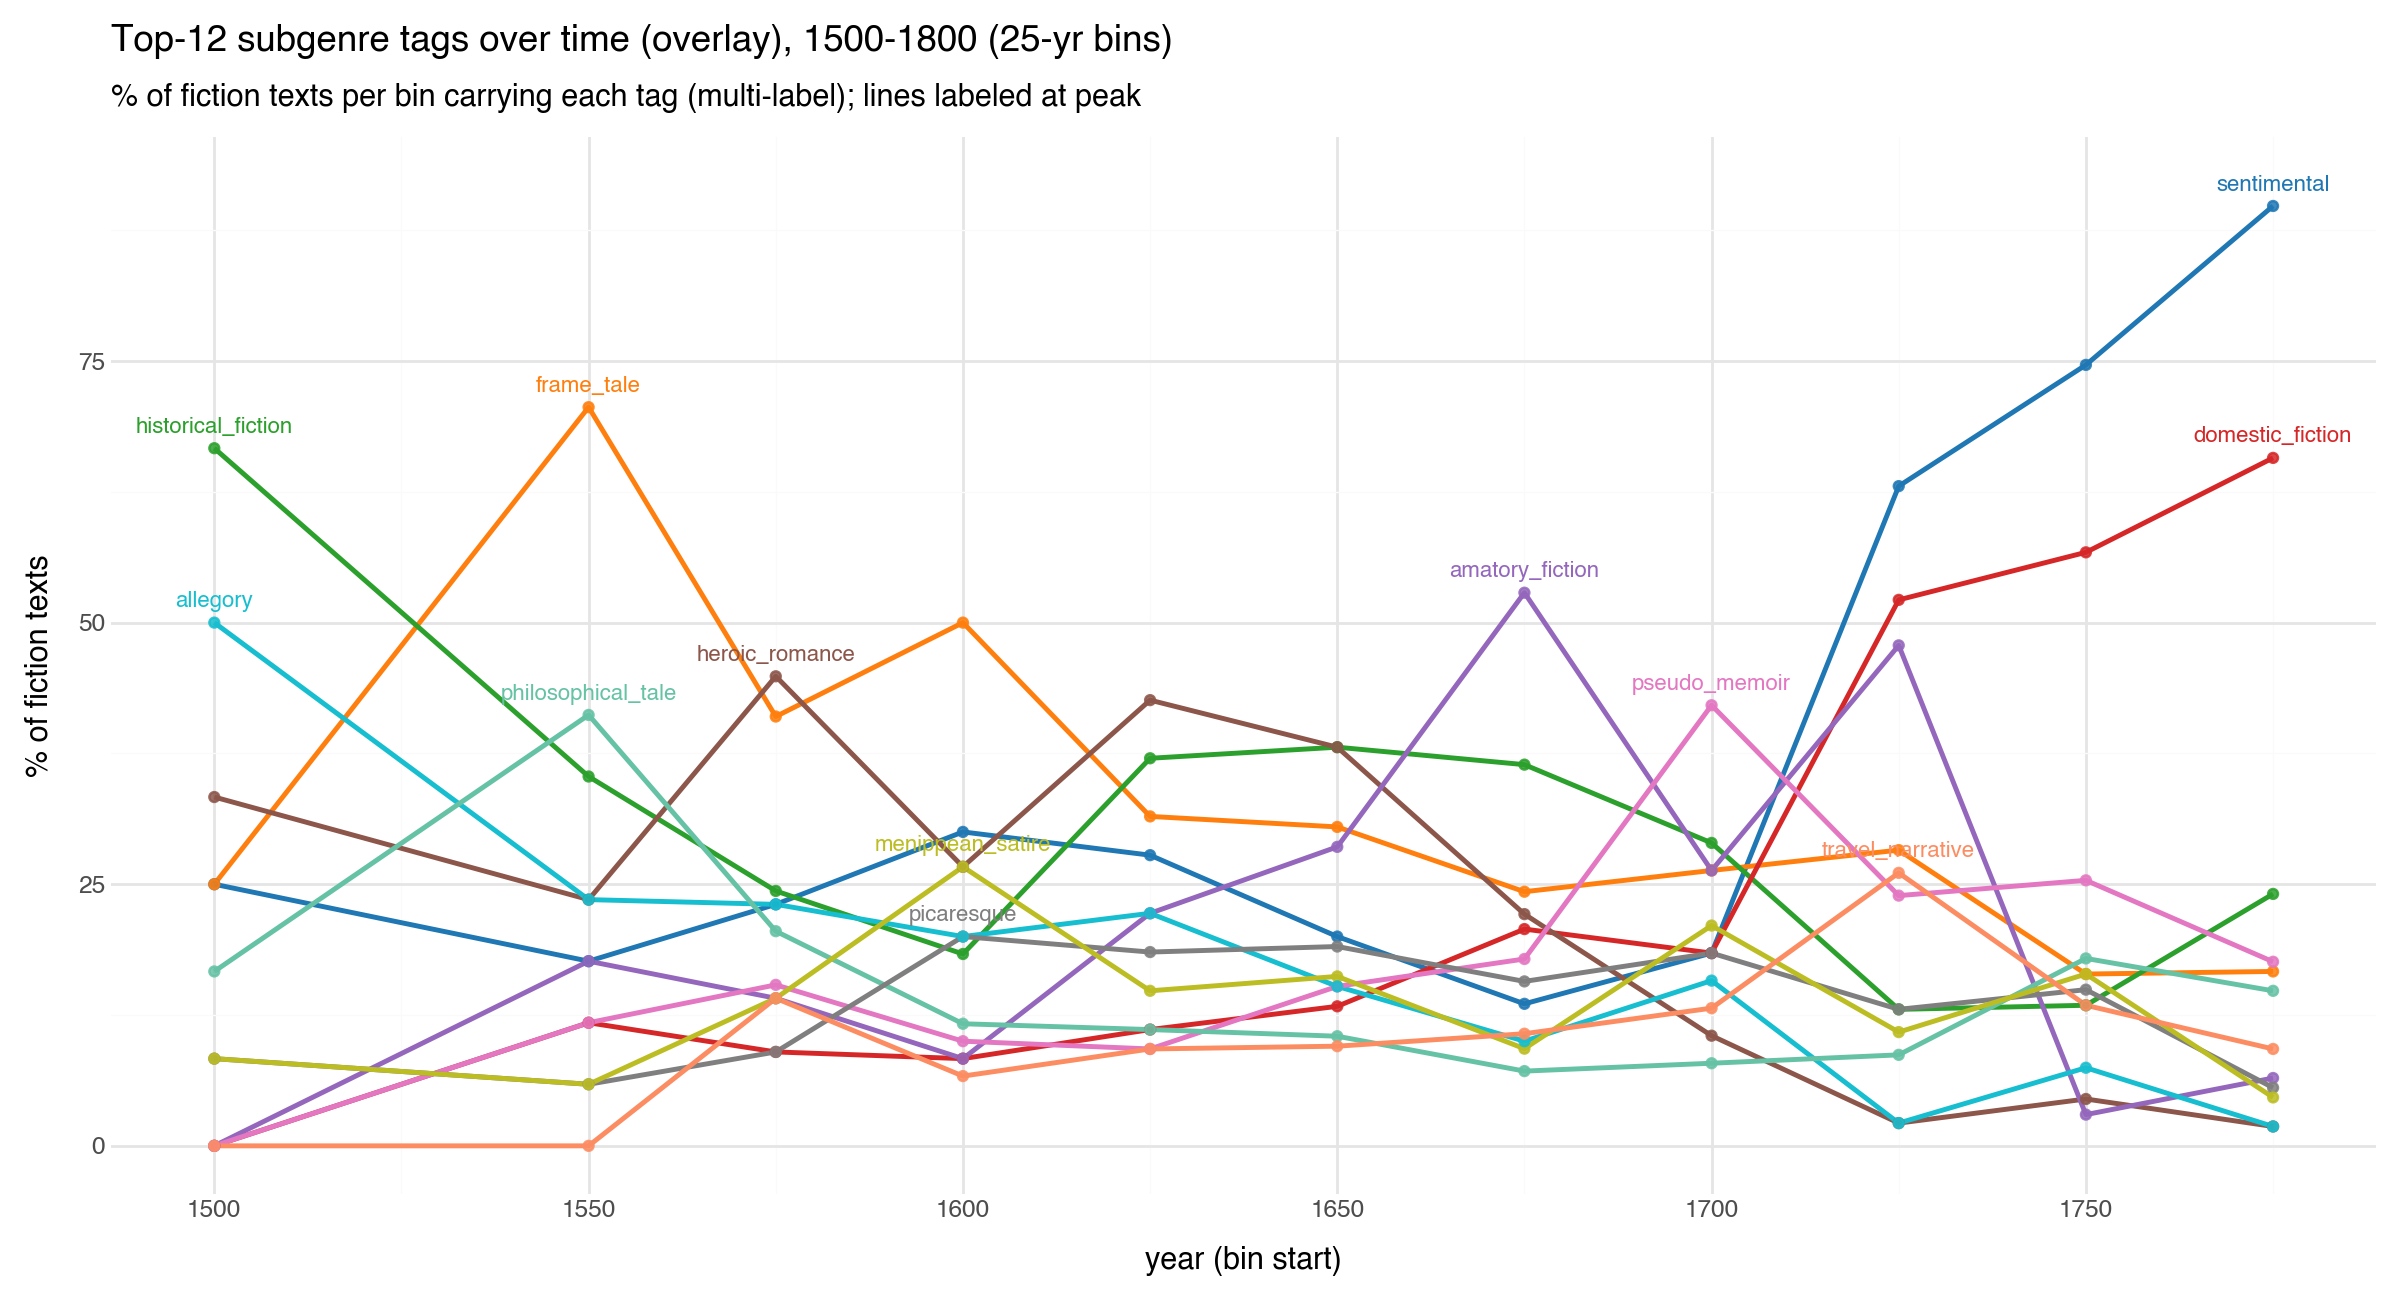

In [6]:
import matplotlib.colors as mcolors
import matplotlib.cm as mcm

# Single-axis line plot, one color per subgenre, label at peak.
tab10_hex = [mcolors.to_hex(c) for c in mcm.tab10.colors]
set2_hex = [mcolors.to_hex(c) for c in mcm.Set2.colors]
palette12 = tab10_hex + set2_hex[:2]
sg_palette = dict(zip(top_tags, palette12))

peak_rows_sg = (sg_long.sort_values('pct', ascending=False)
                .groupby('subgenre', as_index=False, observed=True)
                .first())

p_sg_overlay = (p9.ggplot(sg_long, p9.aes(x='bin', y='pct', color='subgenre'))
                + p9.geom_line(size=1.0)
                + p9.geom_point(size=1.5, alpha=0.85)
                + p9.geom_text(p9.aes(label='subgenre'),
                               data=peak_rows_sg,
                               nudge_y=2.0, size=8, fontweight='bold',
                               show_legend=False)
                + p9.scale_color_manual(values=sg_palette, breaks=top_tags)
                + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
                + p9.labs(
                    title=f'Top-{TOP_K} subgenre tags over time (overlay), 1500-1800 (25-yr bins)',
                    subtitle='% of fiction texts per bin carrying each tag (multi-label); lines labeled at peak',
                    x='year (bin start)', y='% of fiction texts',
                    color='',
                )
                + p9.theme_minimal()
                + p9.theme(figure_size=(12, 6.5),
                           legend_position='none'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_top12_25y_overlay.png')
p_sg_overlay.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_sg_overlay

## 4. The amatory → sentimental → domestic transition

lltm-claude's headline finding: amatory_fiction surges 1650-99, sentimental dominates 1750-99 (80% of texts), domestic_fiction rises 0 → 109 in the same period. Plot all three on one axis.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_amatory_sentimental_domestic_25y.png


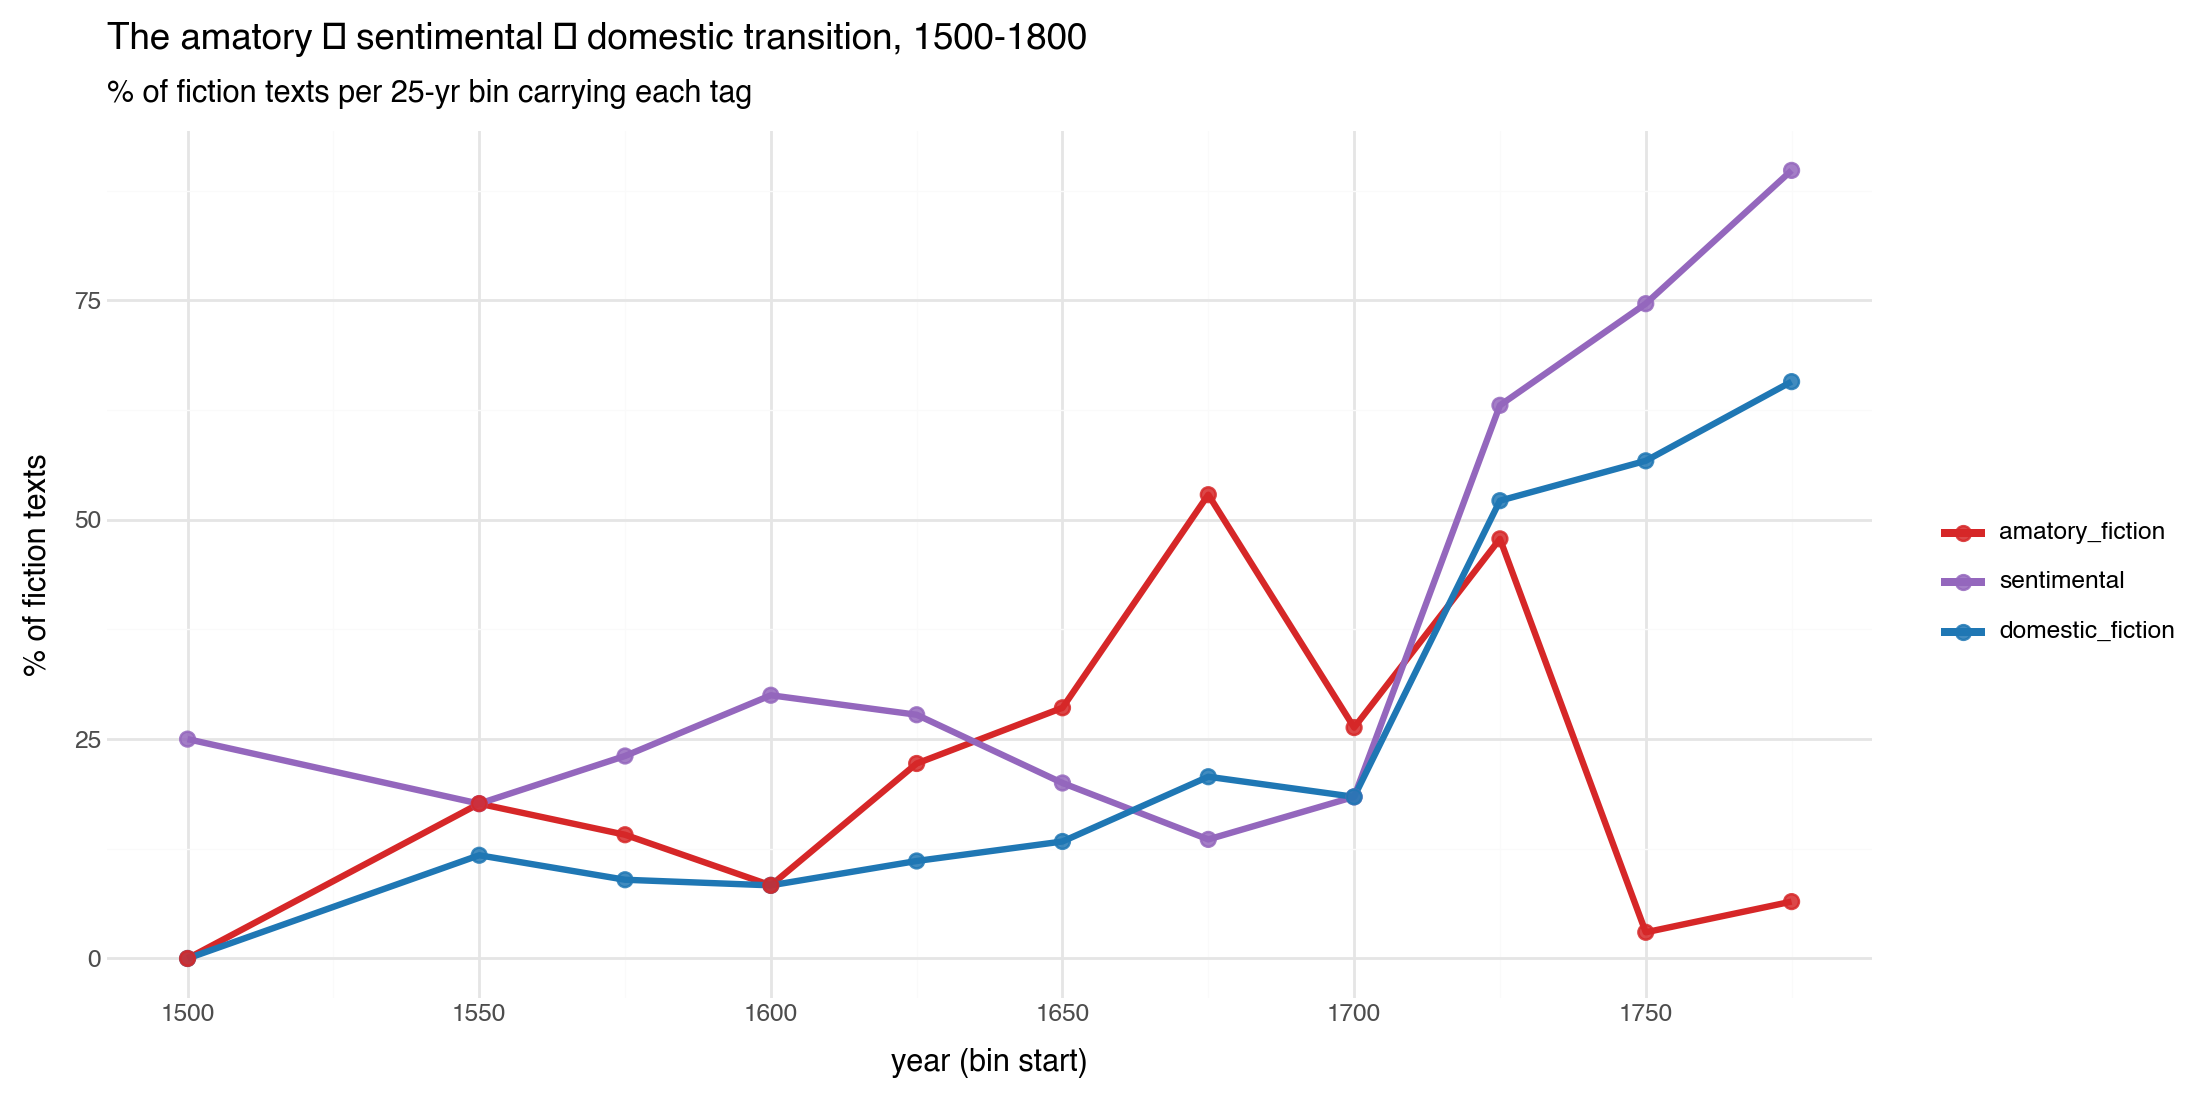

In [7]:
focus = ['amatory_fiction', 'sentimental', 'domestic_fiction']
focus_long = sg_long[sg_long['subgenre'].isin(focus)].copy()
focus_long['subgenre'] = pd.Categorical(focus_long['subgenre'], categories=focus, ordered=True)

p_trans = (p9.ggplot(focus_long, p9.aes(x='bin', y='pct', color='subgenre'))
           + p9.geom_line(size=1.3)
           + p9.geom_point(size=2.5, alpha=0.85)
           + p9.scale_color_manual(values={
               'amatory_fiction':  '#d62728',  # red (older)
               'sentimental':      '#9467bd',  # purple (transition)
               'domestic_fiction': '#1f77b4',  # blue (newer)
           })
           + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
           + p9.labs(
               title='The amatory → sentimental → domestic transition, 1500-1800',
               subtitle=f'% of fiction texts per 25-yr bin carrying each tag',
               x='year (bin start)', y='% of fiction texts',
               color='',
           )
           + p9.theme_minimal()
           + p9.theme(figure_size=(11, 5.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_amatory_sentimental_domestic_25y.png')
p_trans.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_trans

## 5. Abstractness — subgenre vs. century, decomposition

Whole-text abstractness from `abstraction.scores_en` (negated `Abs-Conc.Median.median`, + = abstract). Three views:

1. **2D mean table** — abstractness for each (subgenre × 25-yr bin), to see joint structure.
2. **Variance decomposition** — fit `abs ~ year`, `abs ~ subgenres`, `abs ~ year + subgenres`. Compare R²s; the difference attributes the explanatory work between the two.
3. **Per-subgenre coefficients controlling for year** — which subgenres still have a significant effect on abstractness once the long-run time trend is removed.

Multi-label note: each text can carry several subgenre tags, so dummies aren't mutually exclusive. Coefficients should be read as "marginal effect of carrying this tag, controlling for all others".

In [8]:
import clickhouse_connect
ch = clickhouse_connect.get_client(host='localhost', port=8123,
                                   username='lltk', password='lltk')
ids = fic['source'].tolist()
sc = ch.query_df(
    "SELECT _id, `Abs-Conc.Median.median` AS raw "
    "FROM abstraction.scores_en WHERE _id IN %(ids)s",
    parameters={'ids': ids},
).drop_duplicates('_id')
sc['abs_score'] = -sc['raw']
ch.close()

work = fic.merge(sc[['_id', 'abs_score']], left_on='source', right_on='_id', how='inner')
work = work[work['year'].notna() & work['abs_score'].notna()].copy()
work['bin'] = (work['year'] // 25 * 25).astype(int)
print(f'{len(work):,} fiction texts with year + abstractness + subgenres')

# Long-format for table
rows = []
for _, r in work.iterrows():
    for tag in r['subgenres']:
        rows.append({'tag': tag, 'bin': r['bin'], 'abs': r['abs_score']})
exploded = pd.DataFrame(rows)

top_for_table = [t for t, _ in sg_counter.most_common(12)]
table = (exploded[exploded['tag'].isin(top_for_table)]
         .groupby(['tag', 'bin'])['abs'].mean()
         .unstack('bin').round(2)
         .loc[top_for_table])
print('\nMean abstractness by subgenre x 25-yr bin:')
print(table.to_string())

749 fiction texts with year + abstractness + subgenres

Mean abstractness by subgenre x 25-yr bin:
bin                 1475  1500  1525  1550  1575  1600  1625  1650  1675  1700  1725  1750  1775  1800
tag                                                                                                   
sentimental         0.14  0.08  0.32  0.50  0.43  0.41  0.48  0.55  0.51  0.45  0.59  0.58  0.56  0.51
frame_tale         -0.10  0.17  0.35  0.36  0.33  0.28  0.38  0.49  0.42  0.42  0.51  0.59  0.52  0.37
historical_fiction  0.18  0.08   NaN  0.36  0.24  0.40  0.43  0.57  0.53  0.41  0.52  0.55  0.55  0.47
domestic_fiction     NaN   NaN   NaN  0.64  0.40  0.43  0.47  0.50  0.53  0.50  0.62  0.63  0.59  0.48
amatory_fiction      NaN   NaN  0.32  0.53  0.33  0.41  0.47  0.58  0.60  0.60  0.62  0.71  0.66   NaN
heroic_romance      0.18  0.10  0.32  0.43  0.32  0.42  0.41  0.56  0.52  0.58  0.45  0.72  0.59  0.18
pseudo_memoir      -0.15   NaN   NaN  0.01  0.17  0.27  0.15  0.32  0.35  0.3

In [9]:
# Variance decomposition. Restrict to subgenres with n >= 30 to avoid noisy
# dummies. Center year so the intercept is meaningful at mid-period.
import numpy as np
from sklearn.linear_model import LinearRegression

MIN_N_DUMMY = 30
elig_tags = [t for t, n in sg_counter.most_common() if n >= MIN_N_DUMMY]
print(f'Using {len(elig_tags)} subgenre dummies (each with n >= {MIN_N_DUMMY})')

# Build feature matrices
X_year = (work[['year']].values.astype(float) - work['year'].mean())
X_sg = np.array([[1.0 if t in tags else 0.0 for t in elig_tags]
                 for tags in work['subgenres']])
y = work['abs_score'].values
n = len(y)

def r2(X):
    return LinearRegression().fit(X, y).score(X, y)

r2_year = r2(X_year)
r2_sg = r2(X_sg)
r2_both = r2(np.hstack([X_year, X_sg]))

# Adjusted R^2 to penalize the wide subgenre model
def adj(r2_val, k):
    return 1 - (1 - r2_val) * (n - 1) / (n - k - 1)

print(f'\n--- Variance decomposition (n = {n}) ---')
print(f'  R^2  year only       = {r2_year:.4f}   adj = {adj(r2_year, 1):.4f}   (1 df)')
print(f'  R^2  subgenres only  = {r2_sg:.4f}   adj = {adj(r2_sg, len(elig_tags)):.4f}   ({len(elig_tags)} df)')
print(f'  R^2  year + subgenre = {r2_both:.4f}   adj = {adj(r2_both, len(elig_tags) + 1):.4f}')
print()
unique_year = r2_both - r2_sg
unique_sg = r2_both - r2_year
shared = r2_year + r2_sg - r2_both
print(f'  Unique to YEAR     = {unique_year:.4f}')
print(f'  Unique to SUBGENRE = {unique_sg:.4f}')
print(f'  Shared (collinear) = {shared:.4f}')
print(f'  Total explained    = {r2_both:.4f}')
print()
ratio = unique_sg / unique_year if unique_year > 0 else float('inf')
print(f'  Subgenre/year unique-effect ratio = {ratio:.2f}x')

Using 19 subgenre dummies (each with n >= 30)

--- Variance decomposition (n = 749) ---
  R^2  year only       = 0.1813   adj = 0.1802   (1 df)
  R^2  subgenres only  = 0.4437   adj = 0.4292   (19 df)
  R^2  year + subgenre = 0.4984   adj = 0.4846

  Unique to YEAR     = 0.0547
  Unique to SUBGENRE = 0.3171
  Shared (collinear) = 0.1266
  Total explained    = 0.4984

  Subgenre/year unique-effect ratio = 5.80x


Year coef: +0.00106 per year (t = 8.91, p = 4.08e-18)

Subgenre coefficients (effect on abstractness after detrending), sorted:
          subgenre      coef       se            p  signif
  travel_narrative -0.083235 0.023209 3.578501e-04    True
     rogue_fiction -0.082793 0.031856 9.539091e-03    True
        picaresque -0.012789 0.025952 6.223060e-01   False
  menippean_satire -0.010685 0.023896 6.549035e-01   False
          allegory -0.005435 0.023579 8.177799e-01   False
          pastoral  0.004660 0.030936 8.802975e-01   False
            gothic  0.010183 0.036840 7.823145e-01   False
     pseudo_memoir  0.017542 0.020831 4.000265e-01   False
        frame_tale  0.039384 0.015811 1.296119e-02    True
historical_fiction  0.060776 0.018576 1.118944e-03    True
       sentimental  0.068159 0.017509 1.082204e-04    True
  domestic_fiction  0.074642 0.020568 3.042927e-04    True
 scandalous_memoir  0.111467 0.028063 7.835643e-05    True
   conduct_fiction  0.111702 0.024487 5.955615


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_abstractness_coefficients.png


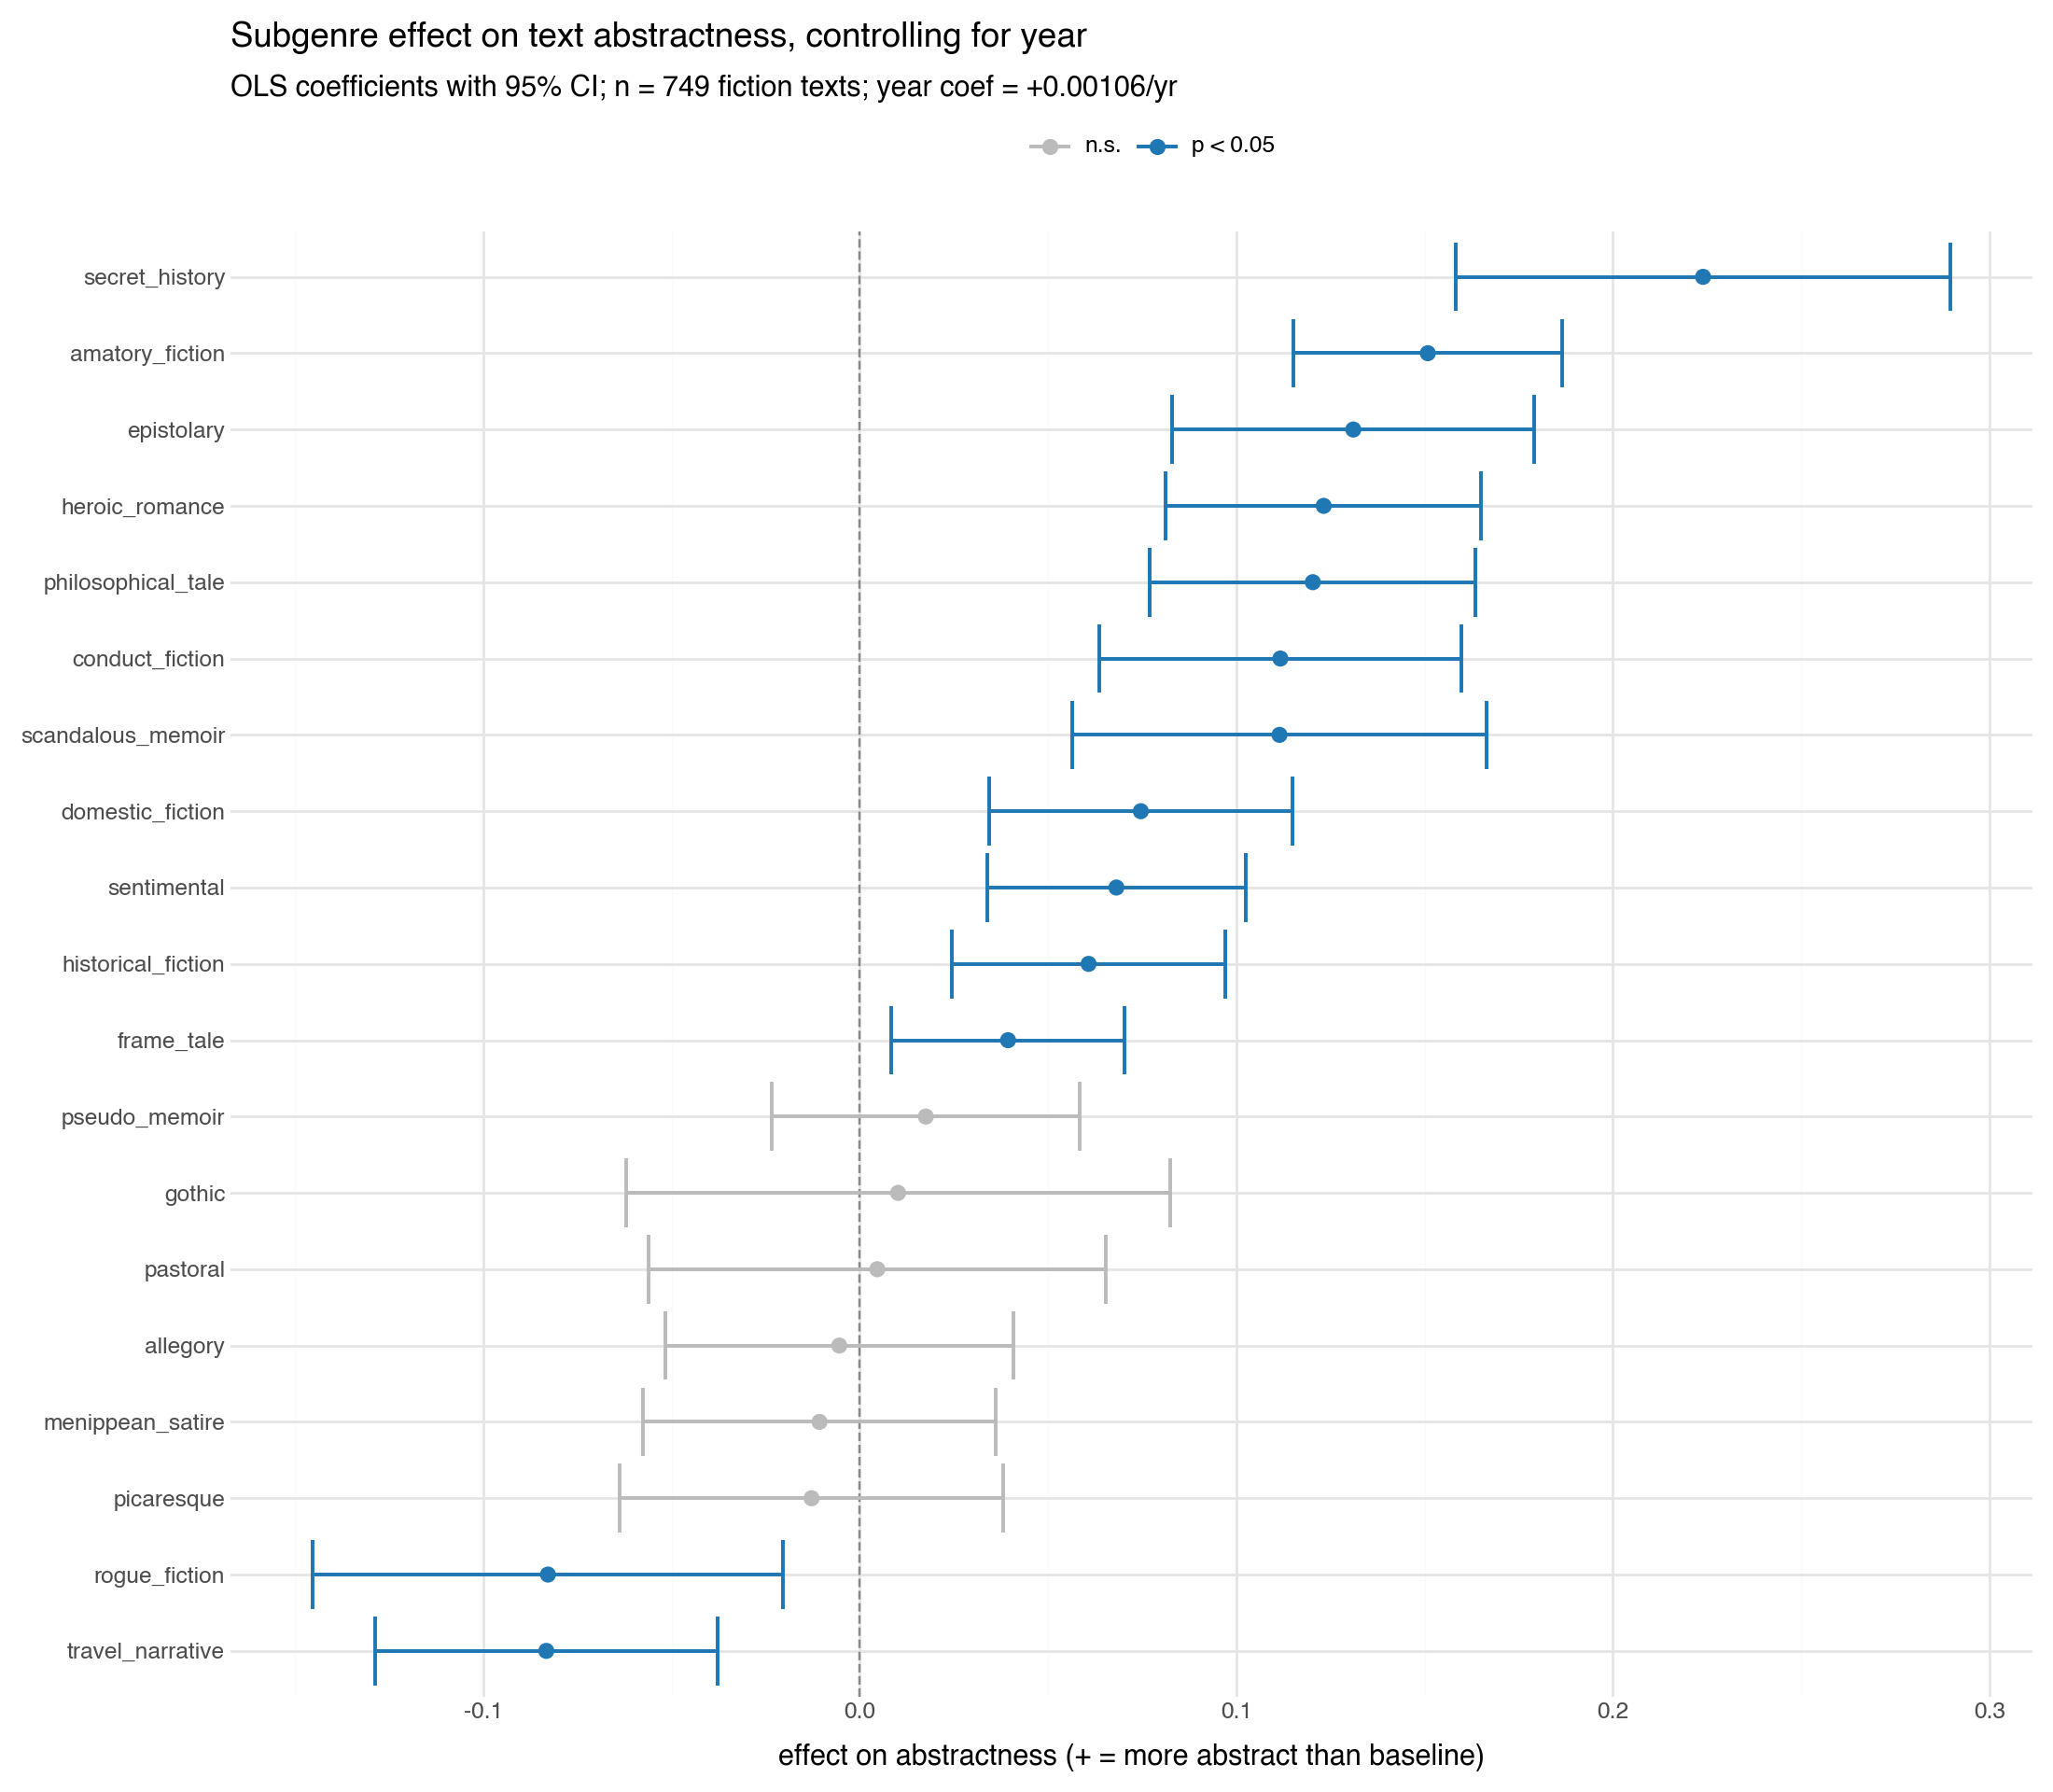

In [10]:
# Per-subgenre coefficient plot: effect on abstractness after detrending year.
# statsmodels gives us SEs and CIs.
import statsmodels.api as sm

X = np.hstack([X_year, X_sg])
X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()

# Coefficient extraction: const, year, then subgenre dummies in order of elig_tags
coefs = ols.params[2:]
ses = ols.bse[2:]
pvals = ols.pvalues[2:]
coef_df = pd.DataFrame({
    'subgenre': elig_tags,
    'coef': coefs,
    'se': ses,
    'p': pvals,
    'lo': coefs - 1.96 * ses,
    'hi': coefs + 1.96 * ses,
}).sort_values('coef')
coef_df['signif'] = coef_df['p'] < 0.05
coef_df['subgenre'] = pd.Categorical(coef_df['subgenre'],
                                     categories=coef_df['subgenre'].tolist(),
                                     ordered=True)

print(f'Year coef: {ols.params[1]:+.5f} per year (t = {ols.tvalues[1]:.2f}, p = {ols.pvalues[1]:.2e})')
print()
print('Subgenre coefficients (effect on abstractness after detrending), sorted:')
print(coef_df[['subgenre', 'coef', 'se', 'p', 'signif']].to_string(index=False))

p_coef = (p9.ggplot(coef_df, p9.aes(x='coef', y='subgenre', color='signif'))
          + p9.geom_vline(xintercept=0, linetype='dashed', color='#888888')
          + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.8)
          + p9.geom_point(size=2.5)
          + p9.scale_color_manual(values={True: '#1f77b4', False: '#bbbbbb'},
                                  labels={True: 'p < 0.05', False: 'n.s.'})
          + p9.labs(
              title='Subgenre effect on text abstractness, controlling for year',
              subtitle=f'OLS coefficients with 95% CI; n = {n} fiction texts; year coef = {ols.params[1]:+.5f}/yr',
              x='effect on abstractness (+ = more abstract than baseline)',
              y='',
              color='',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(11, max(5, 0.4 * len(elig_tags) + 2)),
                     legend_position='top'))

out = os.path.join(DROPBOX_FIGS, 'subgenre_abstractness_coefficients.png')
p_coef.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_coef

## 6. Coincidence between subgenre and plot_genre

Two questions on the same set of 749 pre-1800 texts that have subgenre tags + plot_genre labels + whole-text abstractness:

1. **Cross-tab / lift heatmap** — for each (subgenre tag, plot_genre category) pair, compute lift = P(both) / [P(subgenre) · P(plot_genre_cat)]. Lift > 1 = positively associated; <1 = negatively associated. Tells us which Frye/Pavel categories cluster which subgenres.
2. **Variance partition (subgenre vs plot_genre vs year)** — fit `abs ~ year + subgenre`, `abs ~ year + plot_genre`, and `abs ~ year + subgenre + plot_genre`; decompose unique vs shared variance.

749 pre-1800 texts with subgenre + plot_genre + abstractness + year


Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_plot_genre_lift.png

Strongest positive associations (lift > 2.0, n_joint >= 10):
          subgenre                       pg_label  lift  n_joint
  menippean_satire              frye_mode: ironic  5.18       26
  travel_narrative            ending_type: return  3.59       22
        picaresque           moral_source: absent  3.20       28
  menippean_satire           moral_source: absent  3.00       25
        frame_tale     plot_structure: frame_tale  2.98       65
philosophical_tale              frye_mode: ironic  2.82       14
  domestic_fiction     pavel_tradition: synthesis  2.63       63
     pseudo_memoir            ending_type: return  2.63       25
  menippean_satire           mythos: irony_satire  2.50       75
    heroic_romance             frye_mode: romance  2.43      112
  domestic_fiction                 mythos: comedy  2.35      116
        picaresque pavel_tradition: anti_idealist  2.30       95

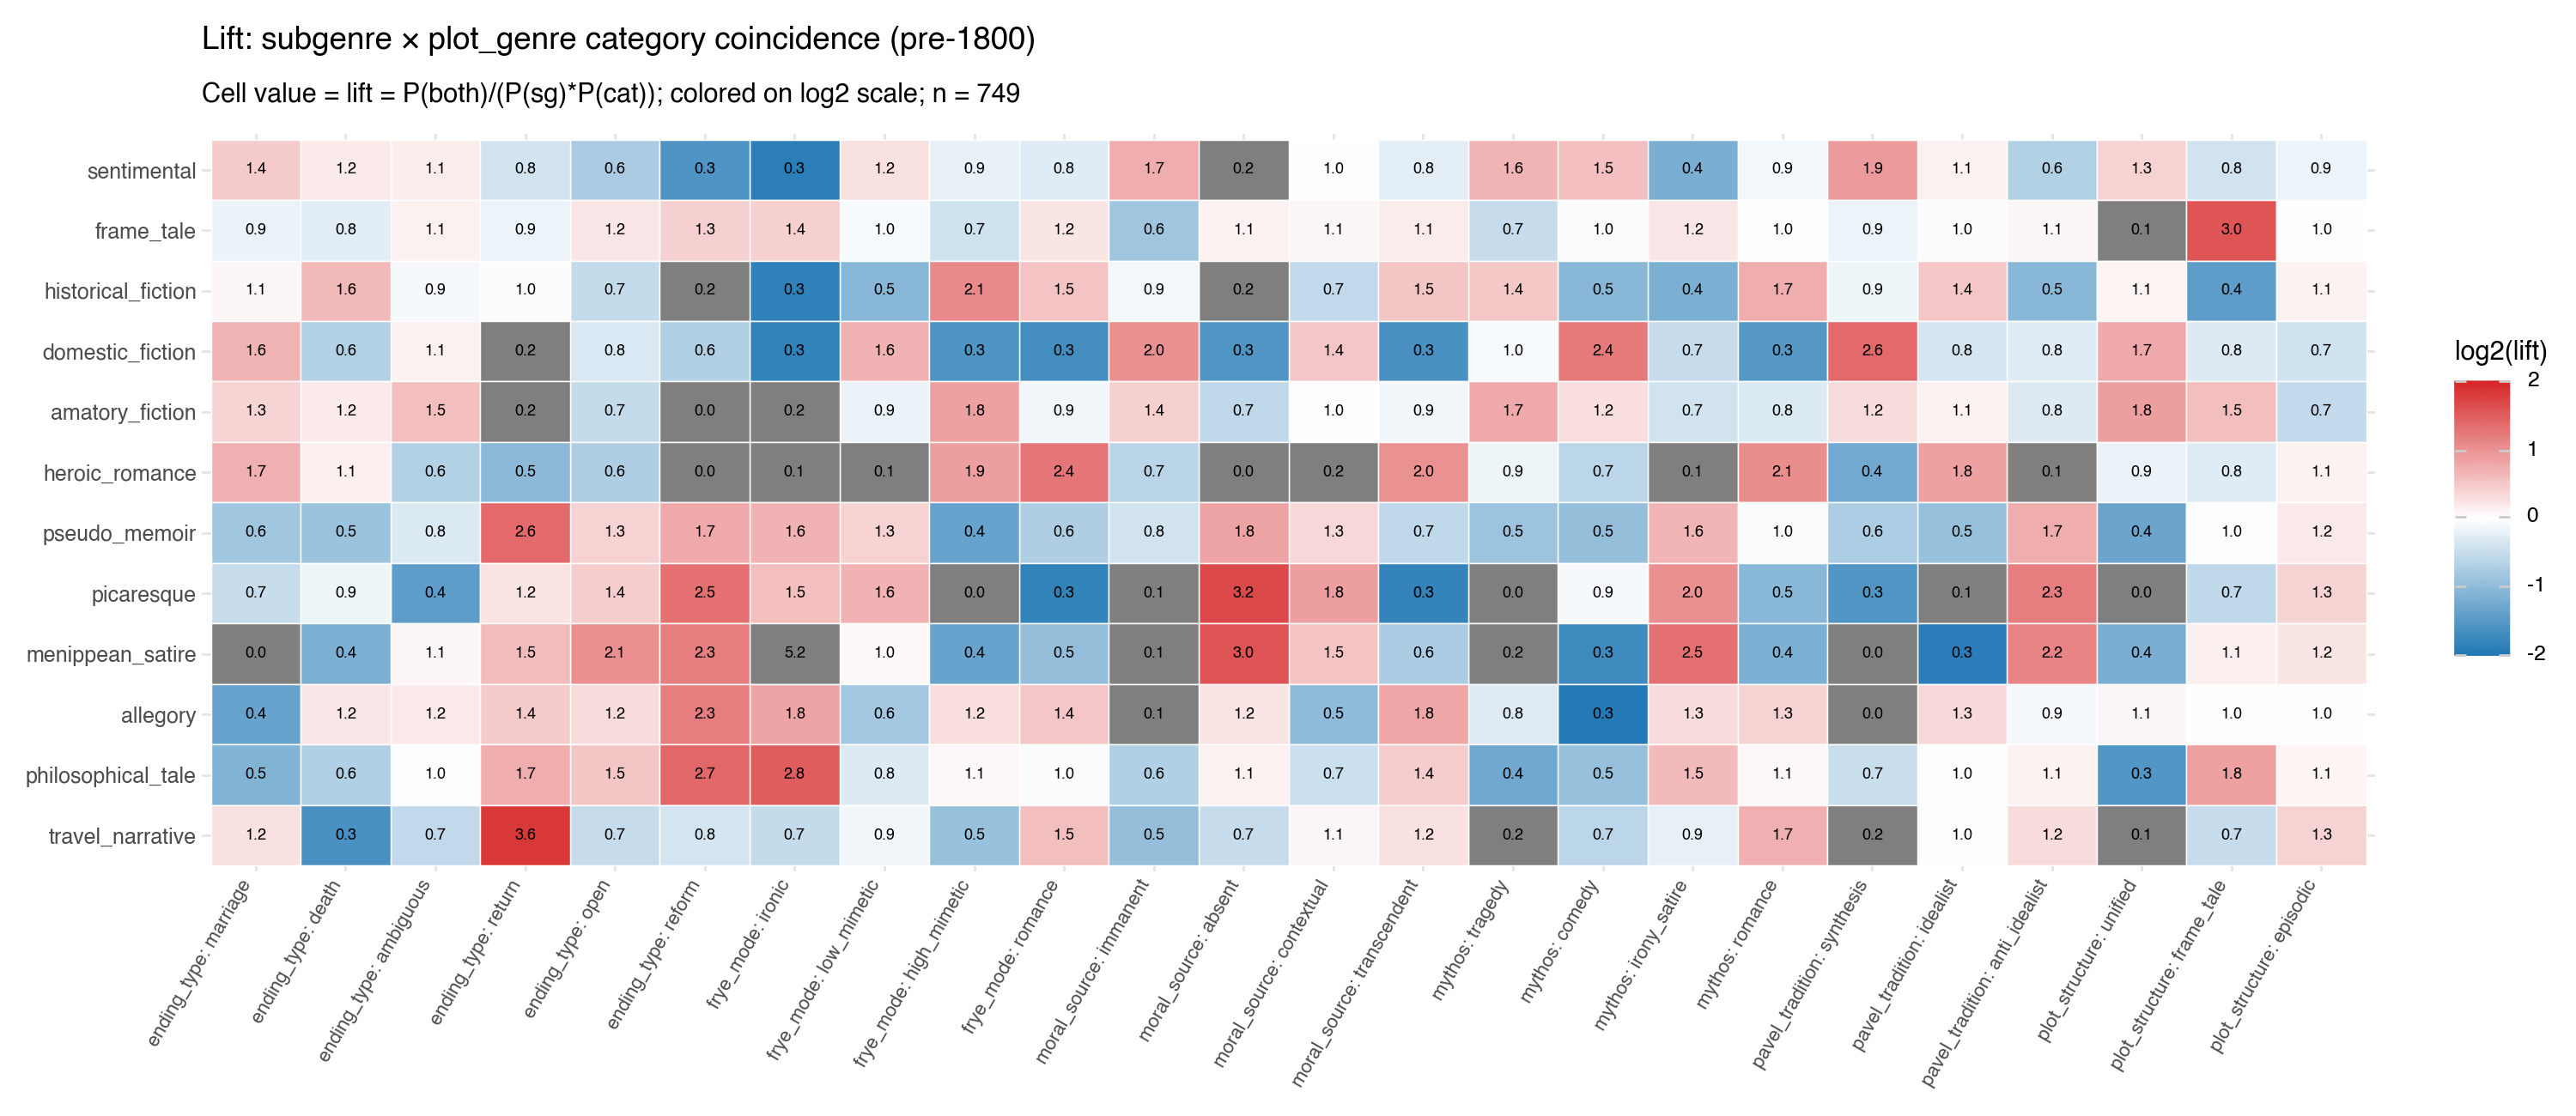

In [11]:
# Load plot_genre annotations + merge with the subgenre+abstractness work-set.
pg_rows = []
for _id, d in iter_task_results('plot_genre'):
    row = {'source': _id}
    for k in ('mythos', 'frye_mode', 'pavel_tradition', 'moral_source',
             'plot_structure', 'ending_type'):
        row[k] = d.get(k)
    pg_rows.append(row)
pg_df = pd.DataFrame(pg_rows)

joint = work.merge(pg_df, on='source', how='inner')
print(f'{len(joint):,} pre-1800 texts with subgenre + plot_genre + abstractness + year')

PG_FIELDS = ['mythos', 'frye_mode', 'pavel_tradition',
             'moral_source', 'plot_structure', 'ending_type']

# Lift table: rows = top-12 subgenres, cols = (field, category) flattened
top12 = [t for t, _ in sg_counter.most_common(12)]
N = len(joint)

lift_rows = []
for sg in top12:
    has_sg = joint['subgenres'].apply(lambda L: sg in L).values
    p_sg = has_sg.mean()
    for f in PG_FIELDS:
        for cat in joint[f].dropna().unique():
            in_cat = (joint[f] == cat).values
            n_cat = in_cat.sum()
            if n_cat < 20:
                continue
            p_cat = in_cat.mean()
            p_joint = (has_sg & in_cat).mean()
            if p_sg == 0 or p_cat == 0:
                continue
            lift = p_joint / (p_sg * p_cat)
            lift_rows.append({
                'subgenre': sg,
                'pg_label': f'{f}: {cat}',
                'field': f,
                'lift': lift,
                'log2_lift': np.log2(lift) if lift > 0 else np.nan,
                'n_joint': int((has_sg & in_cat).sum()),
                'n_cat': int(n_cat),
            })
lift_df = pd.DataFrame(lift_rows)

# Order rows (subgenres) by overall mass, columns by field then by mean log2_lift
sg_order = top12  # most-common first
pg_order = (lift_df.groupby(['field', 'pg_label'])['log2_lift'].mean()
            .reset_index()
            .sort_values(['field', 'log2_lift'])
            ['pg_label'].tolist())
lift_df['subgenre'] = pd.Categorical(lift_df['subgenre'], categories=sg_order[::-1], ordered=True)
lift_df['pg_label'] = pd.Categorical(lift_df['pg_label'], categories=pg_order, ordered=True)

p_lift = (p9.ggplot(lift_df, p9.aes(x='pg_label', y='subgenre', fill='log2_lift'))
          + p9.geom_tile(color='white', size=0.3)
          + p9.geom_text(p9.aes(label='lift'),
                         data=lift_df.assign(lift=lift_df['lift'].round(1)),
                         size=6.5)
          + p9.scale_fill_gradient2(low='#1f77b4', mid='white', high='#d62728',
                                    midpoint=0, limits=(-2, 2))
          + p9.labs(
              title='Lift: subgenre × plot_genre category coincidence (pre-1800)',
              subtitle=f'Cell value = lift = P(both)/(P(sg)*P(cat)); colored on log2 scale; n = {N:,}',
              x='', y='', fill='log2(lift)',
          )
          + p9.theme_minimal()
          + p9.theme(figure_size=(15, 6.5),
                     axis_text_x=p9.element_text(rotation=60, ha='right', size=8),
                     axis_text_y=p9.element_text(size=9)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_plot_genre_lift.png')
p_lift.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')

# Top associations
print('\nStrongest positive associations (lift > 2.0, n_joint >= 10):')
top_pos = lift_df[(lift_df['lift'] > 2.0) & (lift_df['n_joint'] >= 10)] \
    .sort_values('lift', ascending=False).head(20)
print(top_pos[['subgenre', 'pg_label', 'lift', 'n_joint']].round(2).to_string(index=False))

print('\nStrongest negative associations (lift < 0.5, n_cat >= 50):')
top_neg = lift_df[(lift_df['lift'] < 0.5) & (lift_df['n_cat'] >= 50)] \
    .sort_values('lift').head(15)
print(top_neg[['subgenre', 'pg_label', 'lift', 'n_joint']].round(2).to_string(index=False))

p_lift

### 6b. Variance partition: subgenre vs plot_genre vs year

Three nested model comparisons on the joined sample. The interesting question is whether plot_genre adds anything *on top of* subgenre, and vice versa — i.e. how much do the two annotation layers redundantly cover the same variance.

In [12]:
# Build feature matrices on the joint set.
n_j = len(joint)
y_j = joint['abs_score'].values
X_year_j = (joint[['year']].values.astype(float) - joint['year'].mean())

# Subgenre dummies (multi-label, n>=30 in the joint set)
joint_sg_counter = Counter()
for tags in joint['subgenres']:
    for t in tags:
        joint_sg_counter[t] += 1
elig_sg = [t for t, n in joint_sg_counter.most_common() if n >= 30]
X_sg_j = np.array([[1.0 if t in tags else 0.0 for t in elig_sg]
                   for tags in joint['subgenres']])

# Plot_genre dummies (drop most-common per field)
def make_dummies_joint(field):
    s = joint[field].fillna('__missing__')
    dummies = pd.get_dummies(s, prefix=field).astype(float)
    most_common = s.value_counts().index[0]
    ref_col = f'{field}_{most_common}'
    if ref_col in dummies.columns:
        dummies = dummies.drop(columns=[ref_col])
    return dummies
X_pg_j = pd.concat([make_dummies_joint(f) for f in PG_FIELDS], axis=1).values

def fit(X):
    return LinearRegression().fit(X, y_j).score(X, y_j)

r2_y     = fit(X_year_j)
r2_sg    = fit(X_sg_j)
r2_pg    = fit(X_pg_j)
r2_y_sg  = fit(np.hstack([X_year_j, X_sg_j]))
r2_y_pg  = fit(np.hstack([X_year_j, X_pg_j]))
r2_sg_pg = fit(np.hstack([X_sg_j, X_pg_j]))
r2_all   = fit(np.hstack([X_year_j, X_sg_j, X_pg_j]))

print(f'n = {n_j:,}; subgenre dummies = {len(elig_sg)}; plot_genre dummies = {X_pg_j.shape[1]}')
print()
print(f'  R^2 year                 = {r2_y:.4f}')
print(f'  R^2 subgenre             = {r2_sg:.4f}')
print(f'  R^2 plot_genre           = {r2_pg:.4f}')
print(f'  R^2 year + subgenre      = {r2_y_sg:.4f}')
print(f'  R^2 year + plot_genre    = {r2_y_pg:.4f}')
print(f'  R^2 subgenre + plot_genre = {r2_sg_pg:.4f}')
print(f'  R^2 all three            = {r2_all:.4f}')
print()
print('--- 3-way variance partition ---')
unique_year = r2_all - r2_sg_pg
unique_sg   = r2_all - r2_y_pg
unique_pg   = r2_all - r2_y_sg
print(f'  Unique to YEAR        = {unique_year:.4f}')
print(f'  Unique to SUBGENRE    = {unique_sg:.4f}')
print(f'  Unique to PLOT_GENRE  = {unique_pg:.4f}')
print(f'  Shared (any pair/all) = {r2_all - unique_year - unique_sg - unique_pg:.4f}')
print(f'  Total                 = {r2_all:.4f}')
print()
print('--- Pairwise additions (does X add to Y+others?) ---')
print(f'  plot_genre adds, on top of (year + subgenre): {(r2_all - r2_y_sg):.4f}')
print(f'  subgenre   adds, on top of (year + plot_genre): {(r2_all - r2_y_pg):.4f}')
print(f'  year       adds, on top of (subgenre + plot_genre): {(r2_all - r2_sg_pg):.4f}')

n = 749; subgenre dummies = 19; plot_genre dummies = 21

  R^2 year                 = 0.1813
  R^2 subgenre             = 0.4437
  R^2 plot_genre           = 0.2787
  R^2 year + subgenre      = 0.4984
  R^2 year + plot_genre    = 0.3869
  R^2 subgenre + plot_genre = 0.4982
  R^2 all three            = 0.5464

--- 3-way variance partition ---
  Unique to YEAR        = 0.0482
  Unique to SUBGENRE    = 0.1595
  Unique to PLOT_GENRE  = 0.0480
  Shared (any pair/all) = 0.2907
  Total                 = 0.5464

--- Pairwise additions (does X add to Y+others?) ---
  plot_genre adds, on top of (year + subgenre): 0.0480
  subgenre   adds, on top of (year + plot_genre): 0.1595
  year       adds, on top of (subgenre + plot_genre): 0.0482
